# Options Pricing from a Trained MPS Born Machine

Loads a saved MPS bundle, draws Monte Carlo paths by sequential conditional
sampling, and prices four exotic option types:

| Option | Payoff |
|---|---|
| European call | max(S_T − K, 0) |
| Asian call | max(mean(Sₜ) − K, 0) |
| Lookback call | max(max(Sₜ) − K, 0) |
| Up-and-out barrier call | max(S_T − K, 0) · 𝟙[max(Sₜ) < B] |

For the European option the Black-Scholes implied volatility is also computed,
and the implied-vol smile is plotted across a range of strikes.

In [23]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using LinearAlgebra, Statistics, Printf, Plots
using Distributions: Normal, cdf

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


## 1. Configuration

Set the path to a saved MPS bundle and the encoder parameters used when
training it.  The meta dict in the bundle stores `D_max`, `M`, and `m`;
you only need to set `encoder_type` and the grid limits (`S_min`, `S_max`)
which are not persisted automatically.

In [24]:
# ── Path to saved model ────────────────────────────────────────────────────────
mps_file = "mps_heston.jld2"   # adjust to your saved bundle

# ── Encoder type: BasisEncoder, BinaryEncoder, or TrigEncoder ─────────────────
encoder_type = BasisEncoder

# ── Sampling ──────────────────────────────────────────────────────────────────
N_samp   = 10_000   # number of MPS-sampled paths

# ── Option / market parameters ────────────────────────────────────────────────
S0       = 100.0    # spot price
r        = 0.0      # risk-free rate
K_base   = 100.0    # ATM strike for the comparison table
B_level  = 115.0    # barrier level for the up-and-out option

# ── Heston model parameters (must match the model used for training) ──────────
ν0  = 0.04   # initial variance (v0); implied vol ≈ √ν0 ≈ 20%
κ   = 1.0    # mean-reversion speed
θ   = 0.04   # long-run variance
ξ   = 2.0    # vol-of-vol
ρ   = -0.7   # spot/vol correlation
Δt  = 1/250  # time step (daily)

# ── IV smile: strikes as fraction of S0 ───────────────────────────────────────
smile_moneyness = range(0.75, 1.30; length = 30)

0.75:0.01896551724137931:1.3

## 2. Load MPS and Reconstruct Encoder

In [25]:
mps, nll_hist, epoch_saved, meta = load_mps_bundle(mps_file)

M     = meta["M"]     # chain length (time steps)
m     = meta["m"]     # encoder bits / resolution parameter
D_max = meta["D_max"]
T_mat = M / 252.0     # maturity in years (assuming daily steps)

@printf("Loaded MPS: M=%d  m=%d  D_max=%d  epoch=%d  NLL=%.4f\n",
        M, m, D_max, epoch_saved, nll_hist[end])
println("Bond dims: ", [size(mps[j], 3) for j in 1:M-1])

# Reconstruct encoder from meta.
# If the bundle was saved BEFORE the Smin/Smax fix, fall back to manual override.
enc_name = get(meta, "encoder", string(encoder_type))
enc = encoder_type(m)
if haskey(meta, "Smin") && haskey(meta, "Smax")
    enc.Smin = Float64(meta["Smin"])
    enc.Smax = Float64(meta["Smax"])
    @printf("Encoder: %s  grid=[%.2f, %.2f]  d=%d buckets\n",
            enc_name, enc.Smin, enc.Smax, site_dim(enc))
else
    # ── MANUAL FALLBACK ────────────────────────────────────────────────────
    # Bundle was saved without encoder grid info.  Set Smin/Smax here to
    # match the training data range used when the model was trained.
    # Example: enc.Smin = 60.0; enc.Smax = 160.0
    # Alternatively, reload training paths and call fit_grid!(enc, paths).
    @warn "Smin/Smax not in meta. Set enc.Smin and enc.Smax manually in the next cell."
end

Loaded MPS: M=30  m=4  D_max=150  epoch=50  NLL=16.2639
Bond dims: [16, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 16]
Encoder: BasisEncoder  grid=[63.11, 121.66]  d=16 buckets


## 3. Sample Paths

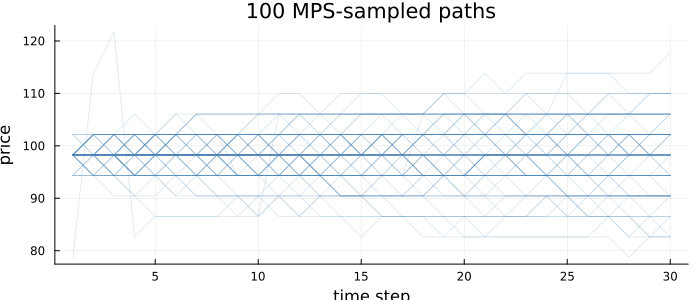

Sampled 10000 paths of length 30
Price range: [63.11, 121.66]


In [26]:
sampled_paths, sampled_xi = sample_paths(enc, mps, N_samp; seed = 42)

@printf("Sampled %d paths of length %d\n", size(sampled_paths)...)
@printf("Price range: [%.2f, %.2f]\n", minimum(sampled_paths), maximum(sampled_paths))

p_paths = plot(sampled_paths[1:100, :]';
    alpha = 0.2, lw = 0.8, color = :steelblue, legend = false,
    xlabel = "time step", ylabel = "price",
    title  = "100 MPS-sampled paths", size = (700, 300))
display(p_paths)

## 4. Heston Reference Simulation

Simulate paths from the same Heston model used to generate the training data.
These serve as the ground-truth reference for option pricing comparisons.

In [27]:
using Random

"""
    simulate_heston(N, M, S0, ν0, κ, θ, ξ, ρ, Δt; seed) -> (paths_S, paths_ν)

Euler–Maruyama discretisation of the Heston stochastic volatility model.
Returns N×M matrices of stock prices and variance paths.
"""
function simulate_heston(N, M, S0, ν0, κ, θ, ξ, ρ, Δt; seed = 42)
    sqdt   = sqrt(Δt)
    out_S  = Matrix{Float64}(undef, N, M)
    out_ν  = Matrix{Float64}(undef, N, M)
    Threads.@threads for i in 1:N
        rng = MersenneTwister(seed + i)
        S   = Float64(S0)
        ν   = Float64(ν0)
        for t in 1:M
            Zs = randn(rng)
            Zν = ρ * Zs + sqrt(1 - ρ^2) * randn(rng)
            S  = S  + sqrt(max(ν, 0)) * S  * sqdt * Zs
            ν  = abs(ν + κ * (θ - ν) * Δt + ξ * sqrt(max(ν, 0)) * sqdt * Zν)
            out_S[i, t] = S
            out_ν[i, t] = ν
        end
    end
    return out_S, out_ν
end

heston_paths, _ = simulate_heston(N_samp, M, S0, ν0, κ, θ, ξ, ρ, Δt)
@printf("Heston: %d paths × %d steps  |  mean S_T = %.3f\n",
        size(heston_paths)..., mean(heston_paths[:, end]))

Heston: 10000 paths × 30 steps  |  mean S_T = 100.033


## 5. Pricing Functions

In [28]:
"""Price four option types on a matrix of paths (N × M).  Returns a NamedTuple."""
function price_options(paths::AbstractMatrix, K, B; r = 0.0, T = 1.0)
    disc  = exp(-r * T)
    ST    = paths[:, end]
    Savg  = vec(mean(paths; dims = 2))
    Smax  = vec(maximum(paths; dims = 2))
    (
        european = disc * mean(max.(ST  .- K, 0.0)),
        asian    = disc * mean(max.(Savg .- K, 0.0)),
        lookback = disc * mean(max.(Smax .- K, 0.0)),
        barrier  = disc * mean(max.(ST  .- K, 0.0) .* (Smax .< B)),
    )
end

"""Black-Scholes European call price."""
function bs_call(S, K, T, σ; r = 0.0)
    d1 = (log(S / K) + (r + σ^2 / 2) * T) / (σ * sqrt(T))
    d2 = d1 - σ * sqrt(T)
    S * cdf(Normal(), d1) - K * exp(-r * T) * cdf(Normal(), d2)
end

"""Newton–bisection implied vol from a call price."""
function implied_vol(price, S, K, T; r = 0.0, tol = 1e-8, max_iter = 200)
    f(σ) = bs_call(S, K, T, σ; r = r) - price
    lo, hi = 1e-5, 10.0
    f(lo) * f(hi) > 0 && return NaN
    for _ in 1:max_iter
        mid = (lo + hi) / 2
        abs(f(mid)) < tol && return mid
        f(lo) * f(mid) < 0 ? (hi = mid) : (lo = mid)
    end
    return (lo + hi) / 2
end

implied_vol

## 5. Comparison Table (ATM, K = K_base)

In [29]:
pm  = price_options(sampled_paths, K_base, B_level; r = r, T = T_mat)
ph  = price_options(heston_paths,  K_base, B_level; r = r, T = T_mat)

# Black-Scholes European reference at σ = 20%
bs_ref   = bs_call(S0, K_base, T_mat, 0.20; r = r)
iv_mps   = implied_vol(pm.european, S0, K_base, T_mat; r = r)
iv_hest  = implied_vol(ph.european, S0, K_base, T_mat; r = r)

println("Option prices  (K = $(K_base),  B = $(B_level),  T = $(round(T_mat; digits=3)) yr)")
println("─"^76)
@printf("%-20s  %10s  %10s  %10s  %10s\n",
        "Type", "MPS MC", "Heston MC", "BS (σ=20%)", "MPS−Heston")
println("─"^76)
@printf("%-20s  %10.4f  %10.4f  %10.4f  %+10.4f\n",
        "European call",  pm.european, ph.european, bs_ref, pm.european - ph.european)
@printf("%-20s  %10.4f  %10.4f  %10s  %+10.4f\n",
        "Asian call",     pm.asian,    ph.asian,    "—",    pm.asian    - ph.asian)
@printf("%-20s  %10.4f  %10.4f  %10s  %+10.4f\n",
        "Lookback call",  pm.lookback, ph.lookback, "—",    pm.lookback - ph.lookback)
@printf("%-20s  %10.4f  %10.4f  %10s  %+10.4f\n",
        "Barrier (U&O)",  pm.barrier,  ph.barrier,  "—",    pm.barrier  - ph.barrier)
println("─"^76)
@printf("Implied vol (European):   MPS = %.2f%%   Heston = %.2f%%   Δ = %.3f%%\n",
        iv_mps * 100, iv_hest * 100, abs(iv_mps - iv_hest) * 100)

Option prices  (K = 100.0,  B = 115.0,  T = 0.119 yr)
────────────────────────────────────────────────────────────────────────────
Type                      MPS MC   Heston MC  BS (σ=20%)  MPS−Heston
────────────────────────────────────────────────────────────────────────────
European call             1.4253      2.9353      2.7524     -1.5100
Asian call                0.5714      1.6577           —     -1.0863
Lookback call             2.9526      4.4658           —     -1.5132
Barrier (U&O)             1.3684      2.7286           —     -1.3602
────────────────────────────────────────────────────────────────────────────
Implied vol (European):   MPS = 10.36%   Heston = 21.33%   Δ = 10.974%


## 6. Option Prices Across Strikes

Sweep strikes from 75 % to 130 % of spot and price each option type.

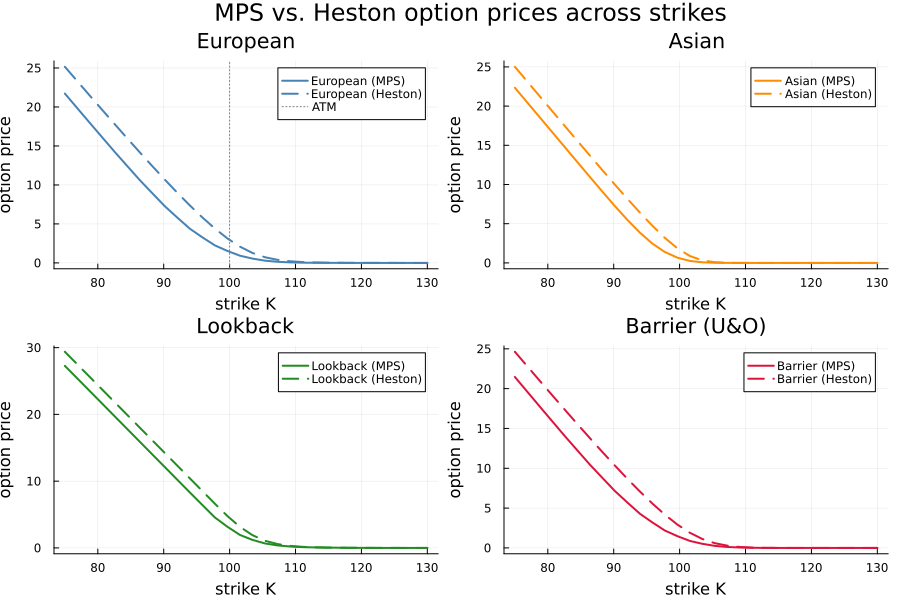

In [30]:
strikes = S0 .* smile_moneyness

eu_prices_mps  = [price_options(sampled_paths, K, B_level; r=r, T=T_mat).european for K in strikes]
as_prices_mps  = [price_options(sampled_paths, K, B_level; r=r, T=T_mat).asian    for K in strikes]
lb_prices_mps  = [price_options(sampled_paths, K, B_level; r=r, T=T_mat).lookback for K in strikes]
ba_prices_mps  = [price_options(sampled_paths, K, B_level; r=r, T=T_mat).barrier  for K in strikes]

eu_prices_hest = [price_options(heston_paths,  K, B_level; r=r, T=T_mat).european for K in strikes]
as_prices_hest = [price_options(heston_paths,  K, B_level; r=r, T=T_mat).asian    for K in strikes]
lb_prices_hest = [price_options(heston_paths,  K, B_level; r=r, T=T_mat).lookback for K in strikes]
ba_prices_hest = [price_options(heston_paths,  K, B_level; r=r, T=T_mat).barrier  for K in strikes]

function _plot_with_heston(strikes, mps_series, hest_series, label, color; kw...)
    p = plot(strikes, mps_series;  lw=2, label=label*" (MPS)",    color=color,   kw...)
    plot!(p, strikes, hest_series; lw=2, label=label*" (Heston)", color=color, ls=:dash)
    p
end

p_eu = _plot_with_heston(strikes, eu_prices_mps, eu_prices_hest, "European",  :steelblue;
    xlabel="strike K", ylabel="option price", title="European")
p_as = _plot_with_heston(strikes, as_prices_mps, as_prices_hest, "Asian",     :darkorange;
    xlabel="strike K", ylabel="option price", title="Asian")
p_lb = _plot_with_heston(strikes, lb_prices_mps, lb_prices_hest, "Lookback",  :forestgreen;
    xlabel="strike K", ylabel="option price", title="Lookback")
p_ba = _plot_with_heston(strikes, ba_prices_mps, ba_prices_hest, "Barrier",   :crimson;
    xlabel="strike K", ylabel="option price", title="Barrier (U&O)")

p_prices = plot(p_eu, p_as, p_lb, p_ba; layout=(2,2), size=(900,600),
    plot_title="MPS vs. Heston option prices across strikes")
vline!.(Ref([S0]); ls=:dot, color=:gray, lw=1, label="ATM")
display(p_prices)

## 7. Implied-Volatility Smile

Invert Black-Scholes for the European call at each strike.  Deviations from
the flat 20 % line reveal skewness or fat-tail structure learned by the MPS.

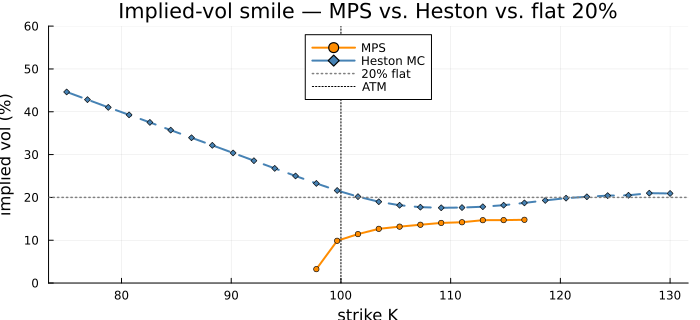

In [31]:
# MPS implied vols — guard against near-zero OTM prices that push
# the bisection to the upper bound (σ=10 = 1000%) instead of NaN.
# Any price below 1e-4 is too small to invert reliably, so we return NaN.
ivols_mps = [p > 1e-4 ? implied_vol(p, S0, K, T_mat; r = r) * 100 : NaN
             for (p, K) in zip(eu_prices_mps, strikes)]

# Heston implied vols (same guard for consistency)
ivols_hest = [p > 1e-4 ? implied_vol(p, S0, K, T_mat; r = r) * 100 : NaN
              for (p, K) in zip(eu_prices_hest, strikes)]

p_smile = plot(strikes, ivols_mps;
    lw=2, marker=:circle, markersize=3, color=:darkorange,
    label = "MPS",
    xlabel = "strike K", ylabel = "implied vol (%)",
    title  = "Implied-vol smile — MPS vs. Heston vs. flat 20%",
    ylims  = (0, 60),
    size = (700, 320), legend = :top)
plot!(p_smile, strikes, ivols_hest;
    lw=2, marker=:diamond, markersize=3, color=:steelblue, ls=:dash,
    label = "Heston MC")
hline!(p_smile, [20.0]; lw=1.5, ls=:dot, color=:gray, label="20% flat")
vline!(p_smile, [S0];   lw=1,   ls=:dot,  color=:black, label="ATM")
display(p_smile)

## 8. NLL Training History

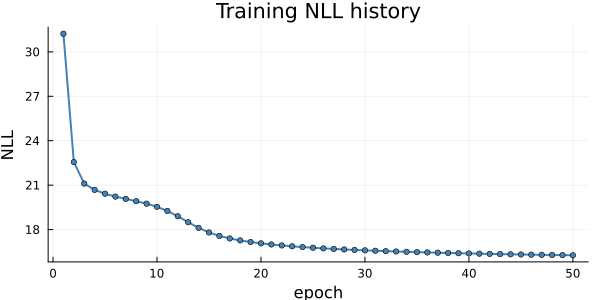

In [32]:
plot(nll_hist;
    lw=2, marker=:circle, markersize=3, color=:steelblue,
    xlabel = "epoch", ylabel = "NLL",
    title  = "Training NLL history",
    legend = false, size = (600, 300))